## Customer Churn Prediction using Machine Learning

## Introduction

### Customer churn prediction is an important problem in the telecom industry. The goal of this project is to predict whether a customer will leave the service or not using machine learning techniques. By identifying churn customers early, businesses can take preventive actions to improve customer retention and reduce revenue loss.

### Importing Libraries

#### This project uses Python libraries such as Pandas and NumPy for data processing, Matplotlib and Seaborn for visualization, and Scikit-learn for building and evaluating machine learning models.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### DATASET DESCRIPTION

#### The dataset contains information about 7043 customers with multiple features related to demographics, account details, and services.

#### Target Variable:
#### - Churn (0 = No, 1 = Yes)

In [30]:
df = pd.read_csv("C:\DataScience\Data_Set\customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df.shape

(7043, 21)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### DATA CLEANING 

- Removed unnecessary column: customerID  
- Converted 'TotalCharges' to numeric  
- Handled missing values  
- Ensured no null values remain

In [33]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
df.drop("customerID",axis=1,inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [36]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [37]:
df.dropna(inplace=True)
df.shape

(7032, 20)

### EXPLORATORY DATA ANAYSIS (EDA)

- Analyze churn distribution  
- Understand feature impact on churn  
- Identify important patterns

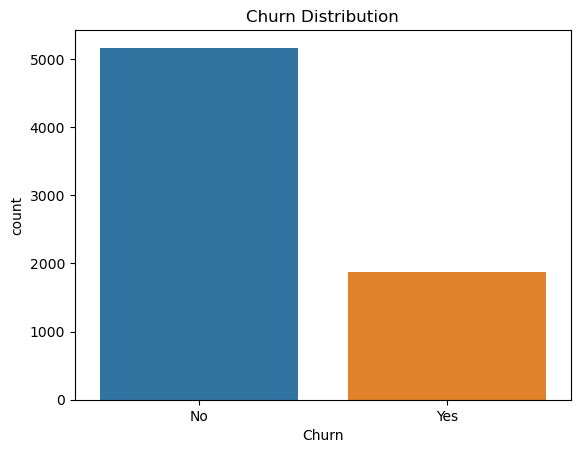

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

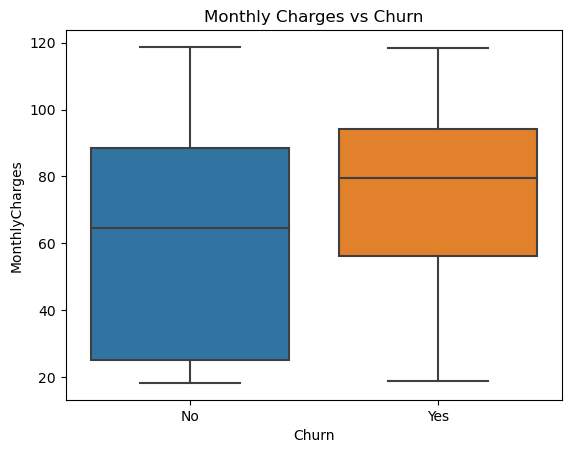

In [39]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

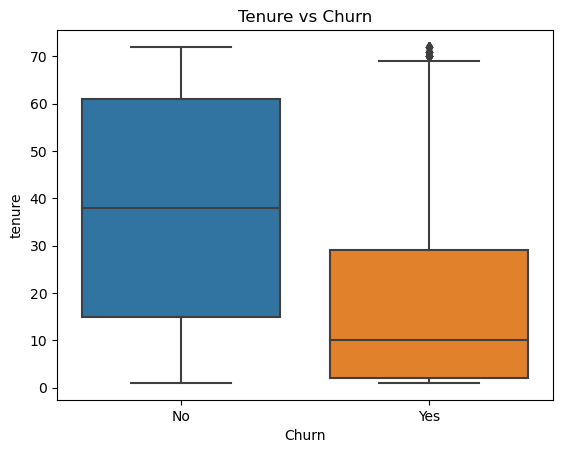

In [40]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

### DATA PREPROCESSING

- Encoded categorical variables into numerical format  
- Created new feature: AvgCharge  
- Split data into training and testing sets (80:20)

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [42]:
df.dtypes

gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
Churn                 int32
dtype: object

In [43]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

### TRAIN TEST SPLIT

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### MODEL BUILDING 

#### The following models were used:

- Logistic Regression  
- Random Forest  
- Support Vector Machine (SVM)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

accuracy1 = accuracy_score(y_test,y_pred1)

print("Accuracy:", accuracy_score(y_test, y_pred1))

Accuracy: 0.7924662402274343


In [46]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier()

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy2 = accuracy_score(y_test, y_pred2)

print("Random Forest Accuracy:", accuracy2)

Random Forest Accuracy: 0.7803837953091685


In [47]:
from sklearn.svm import SVC

model3 = SVC()

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

accuracy3 = accuracy_score(y_test, y_pred3)

print("SVM Accuracy:", accuracy3)

SVM Accuracy: 0.7341862117981521


In [48]:
print ("Logistic Regression:", accuracy1)
print ("Random Forest:", accuracy2)
print ("SVM:", accuracy3)

Logistic Regression: 0.7924662402274343
Random Forest: 0.7803837953091685
SVM: 0.7341862117981521


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred2)
print(cm)

[[925 108]
 [201 173]]


### MODEL EVALUATION

#### Models were evaluated using:

- Accuracy Score  
- Confusion Matrix  
- Classification Report  

#### Initial results showed good accuracy but lower recall for churn customers.

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [51]:
import pandas as pd

feature_importance = pd.Series(model2.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

TotalCharges        0.179101
MonthlyCharges      0.178662
tenure              0.165724
Contract            0.077080
PaymentMethod       0.050998
TechSupport         0.046564
OnlineSecurity      0.044058
InternetService     0.028302
gender              0.028005
PaperlessBilling    0.025283
dtype: float64

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model_balanced = RandomForestClassifier(class_weight="balanced", random_state=42)

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="recall"   
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### MODEL IMPROVEMENT 

#### To improve churn detection:

- Applied hyperparameter tuning (GridSearchCV)  
- Focused on improving recall instead of only accuracy  
- Adjusted prediction threshold from 0.5 to 0.3  

#### This improved the model’s ability to detect churn customers significantly.

In [54]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred_custom = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1033
           1       0.51      0.75      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.74      0.75      1407



### RESULTS

- Accuracy: ~79%  
- Recall improved from 48% to 75%  
- AUC Score: 0.82  

#### The model shows strong performance in identifying churn customers.

In [55]:
df["AvgCharge"] = df["TotalCharges"] / (df["tenure"] + 1)

In [56]:
from sklearn.metrics import roc_auc_score

print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.8261954434154194


### Business Insights

- Customers with high monthly charges are more likely to churn  
- Customers with short tenure have higher churn risk  
- Month-to-month contracts increase churn probability  

### Business Recommendations:

- Encourage long-term contracts  
- Improve customer support  
- Provide targeted retention offers

## Conclusion

### This project successfully predicts customer churn using machine learning techniques. The model achieved strong performance with improved recall and AUC score, making it useful for real-world business decision-making.